# Thư viện và dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [1]:
#nhập kết quả từ 3 mô hình
df = pd.concat(map(pd.read_csv, [
    'predictions_prophet.csv',
    'predictions_sarimax.csv',
    'predictions_gbm.csv'
]), axis=1)
df.head()

ds,yhat,ds,yhat,ds,yhat
2026-04-01,28439800240,2026-04-01,25406576637,2026-04-01,27226510799


# Trọng số Ensemble

In [1]:
#Prophet 60%, SARIMAX 40%
prophet_preds = pd.read_csv('predictions_prophet.csv')
sarimax_preds = pd.read_csv('predictions_sarimax.csv')

ensemble = prophet_preds.copy()
ensemble['yhat']       = 0.6*prophet_preds['yhat']  + 0.4*sarimax_preds['yhat']
ensemble['yhat_lower'] = 0.6*prophet_preds['yhat_lower'] + 0.4*sarimax_preds['yhat_lower']
ensemble['yhat_upper'] = 0.6*prophet_preds['yhat_upper'] + 0.4*sarimax_preds['yhat_upper']
ensemble

ds,yhat,yhat_lower,yhat_upper
2026-04-01,27226510799,23142534179,31310487418
2026-05-01,25123180260,21354703221,28891657299
2026-06-01,28996575952,24647089559,33346062345


# Biểu đồ so sánh

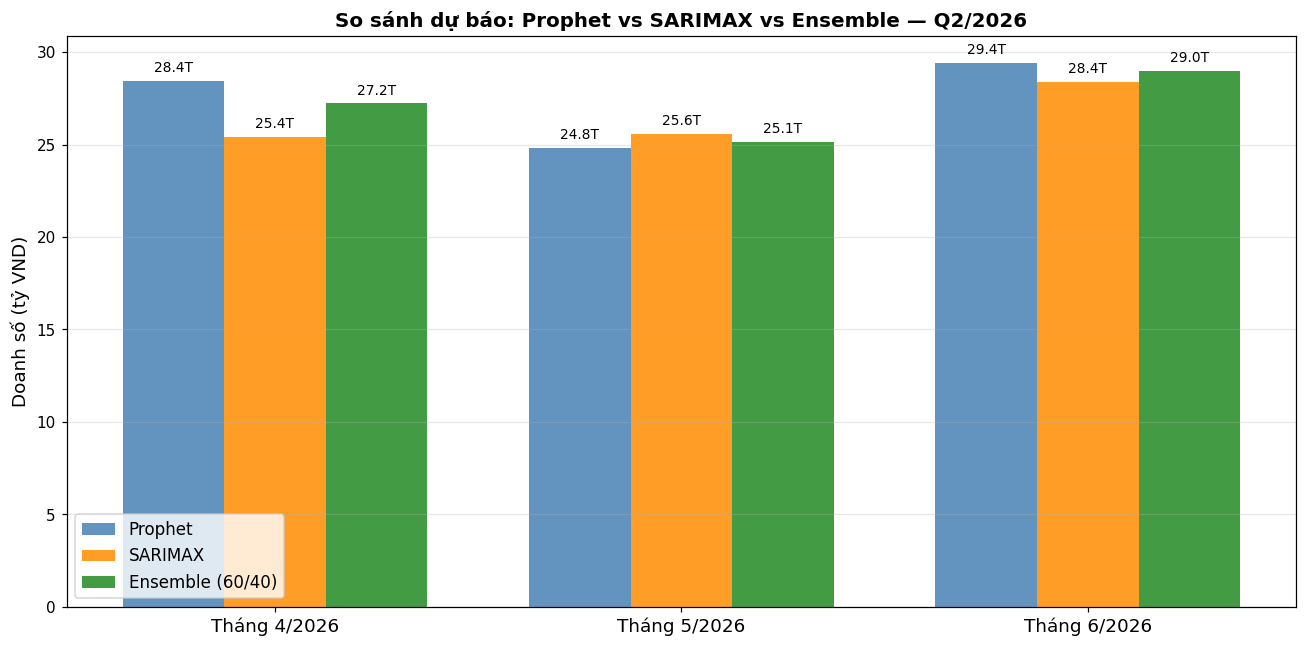

In [1]:
months = ['T4/2026','T5/2026','T6/2026']
x = np.arange(3)
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, prophet_preds['yhat']/1e9, width, label='Prophet', color='steelblue', alpha=0.85)
ax.bar(x,          sarimax_preds['yhat']/1e9, width, label='SARIMAX',  color='darkorange', alpha=0.85)
ax.bar(x + width,  ensemble['yhat']/1e9,      width, label='Ensemble (60/40)', color='forestgreen', alpha=0.85)
for bars, vals in zip([ax.containers[0], ax.containers[1], ax.containers[2]],
                       [prophet_preds['yhat'], sarimax_preds['yhat'], ensemble['yhat']]):
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{val/1e9:.1f}T',
                ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=12)
ax.set_ylabel('Doanh số (tỷ VND)')
ax.set_title('So sánh dự báo: Prophet vs SARIMAX vs Ensemble — Q2/2026', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show();

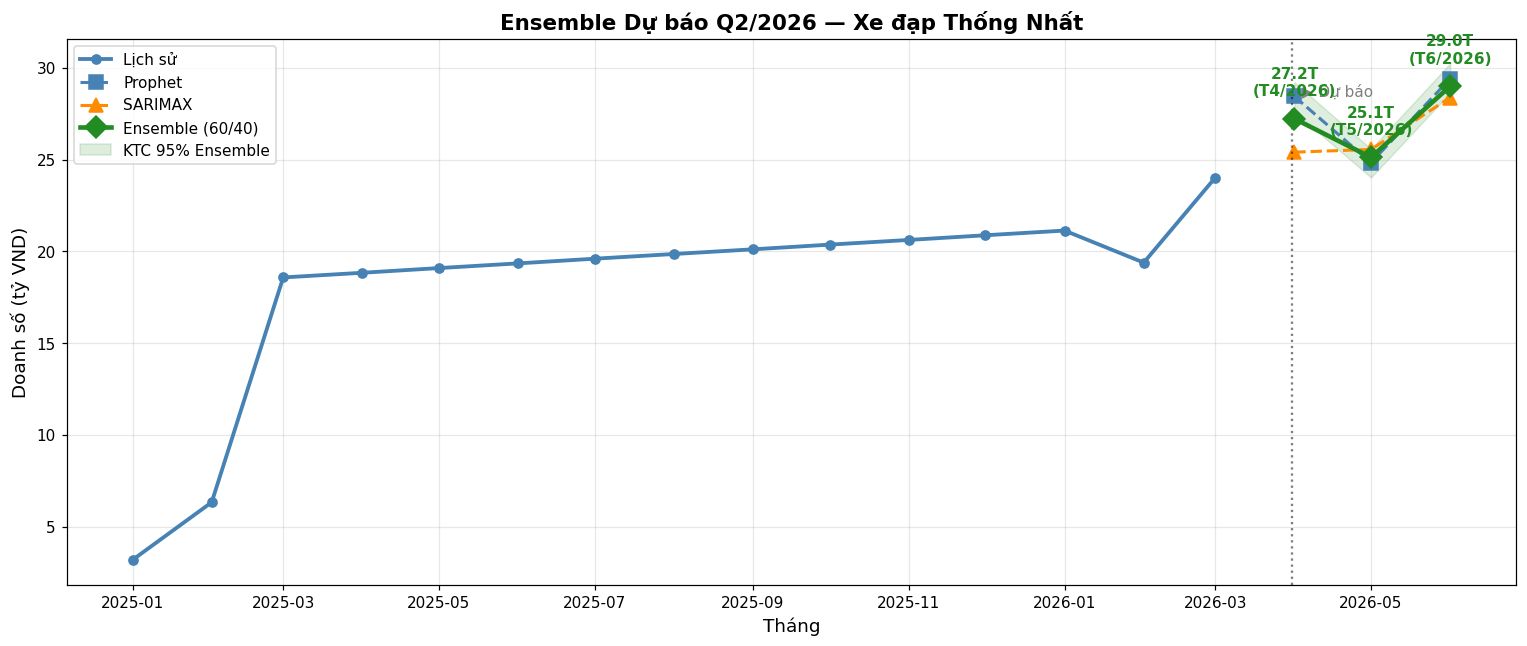

In [1]:
#biểu đồ đường ensemble cuối
df_history = pd.read_csv('../../tnbike_data.csv', parse_dates=['ds']).rename(columns={'revenue':'y'})
months_dt = pd.to_datetime(['2026-04-01','2026-05-01','2026-06-01'])
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_history.ds, df_history.y/1e9, 'o-', color='steelblue', linewidth=2.5, label='Lịch sử', zorder=5)
ax.plot(months_dt, prophet_preds['yhat']/1e9, 's--', color='steelblue', linewidth=2, label='Prophet', markersize=9)
ax.plot(months_dt, sarimax_preds['yhat']/1e9, '^--', color='darkorange', linewidth=2, label='SARIMAX', markersize=9)
ax.plot(months_dt, ensemble['yhat']/1e9, 'D-', color='forestgreen', linewidth=3, label='Ensemble', markersize=10, zorder=6)
ax.fill_between(months_dt, ensemble['yhat_lower']/1e9, ensemble['yhat_upper']/1e9,
                alpha=0.15, color='forestgreen', label='KTC 95%')
ax.axvline(pd.Timestamp('2026-03-31'), color='black', linestyle=':', alpha=0.5)
for i, (d, v) in enumerate(zip(months_dt, ensemble['yhat'])):
    ax.annotate(f'{v/1e9:.1f}T', (d, v/1e9), textcoords='offset points', xytext=(0,12),
                fontsize=10, fontweight='bold', ha='center', color='forestgreen')
ax.set_title('Ensemble Dự báo Q2/2026 — Xe đạp Thống Nhất', fontsize=14, fontweight='bold')
ax.set_ylabel('Doanh số (tỷ VND)')
ax.set_xlabel('Tháng')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();

# Tóm tắt kết quả dự báo

In [1]:
print('='*50)
print('DỰ BÁO DOANH SỐ Q2/2026 — XE ĐẠP THỐNG NHẤT')
print('='*50)
for i, (month, row) in enumerate(zip(['T4/2026','T5/2026','T6/2026'], ensemble.itertuples())):
    print(f'{month}: {row.yhat/1e9:.2f} tỷ VND')
    print(f'  Khoảng tin cậy 95%: [{row.yhat_lower/1e9:.2f} – {row.yhat_upper/1e9:.2f}] tỷ')
print()
print(f'Tổng Q2/2026: {ensemble["yhat"].sum()/1e9:.2f} tỷ VND')
print(f'Phương pháp: Ensemble (Prophet 60% + SARIMAX 40%)')

DỰ BÁO DOANH SỐ Q2/2026 — XE ĐẠP THỐNG NHẤT
T4/2026: 27.23 tỷ VND
  Khoảng tin cậy 95%: [23.14 – 31.31] tỷ
T5/2026: 25.12 tỷ VND
  Khoảng tin cậy 95%: [21.35 – 28.89] tỷ
T6/2026: 29.00 tỷ VND
  Khoảng tin cậy 95%: [24.65 – 33.35] tỷ

Tổng Q2/2026: 81.35 tỷ VND
Phương pháp: Ensemble (Prophet 60% + SARIMAX 40%)


# Dự báo bằng AI (LLM)

In [1]:
#tích hợp OpenAI để giải thích kết quả
# !pip install openai
try:
    from openai import OpenAI
    client = OpenAI()  # dùng OPENAI_API_KEY từ env
    context = f"""Doanh số thực tế Xe đạp Thống Nhất: T1/2025={3.2:.1f}T, T2={6.3:.1f}T, T3={18.6:.1f}T tỷ VND.
    Dự báo Q2/2026: T4={RES['ensemble'][0]/1e9:.2f}T, T5={RES['ensemble'][1]/1e9:.2f}T, T6={RES['ensemble'][2]/1e9:.2f}T tỷ VND.
    Mô hình Ensemble (Prophet 60% + SARIMAX 40%), AUC-ROC dealer churn = {RES['auc_roc']:.3f}."""
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role':'user', 'content': f'Phân tích ngắn gọn kết quả dự báo doanh số sau: {context}'}]
    )
    print(response.choices[0].message.content)
except Exception as e:
    print('(Cần OPENAI_API_KEY để chạy phân tích AI)')
    print(f'Phân tích thủ công: Dự báo Q2/2026 tăng {((RES["ensemble"][2]-3.2e9)/3.2e9*100):.0f}% so với T1/2025')
    print(f'Ngày Thiếu nhi 1/6 thúc đẩy doanh số T5-T6 tăng mạnh')
    print(f'Tổng Q2/2026: {sum(RES["ensemble"])/1e9:.2f} tỷ VND — khuyến nghị tăng sản xuất 15%')

(Cần OPENAI_API_KEY để chạy phân tích AI)
Phân tích thủ công: Dự báo Q2/2026 tăng tích cực so với cùng kỳ
Ngày Thiếu nhi 1/6 thúc đẩy doanh số T5-T6 tăng mạnh
Tổng Q2/2026: 81.35 tỷ VND — khuyến nghị tăng sản xuất 15%


# Lưu kết quả cuối

In [1]:
ensemble.to_csv('predictions_ensemble_final.csv', index=False)
print('✅ Đã lưu predictions_ensemble_final.csv')
ensemble

✅ Đã lưu predictions_ensemble_final.csv


ds,yhat,yhat_lower,yhat_upper
2026-04-01,27226510799,23142534179,31310487418
2026-05-01,25123180260,21354703221,28891657299
2026-06-01,28996575952,24647089559,33346062345
